# 1. Analyser le dataset (statistiques descriptives, visualisation, corrélations) 


L’objectif est de développer un modèle de machine learning permettant de prédire la présence de calculs biliaires à partir des seules données cliniques non-imagées collectées auprès de 319 patients, en mettant en œuvre un pipeline associant :

sélection automatique de variables (SelectKBest, score f_classif)

un modèle Random Forest imposé (puis comparaison avec deux modèles annexes)

validation croisée systématique à 5-folds

# 2. Présentation du dataset
319 lignes (patients)

38 variables cliniques : démographie, impédancemétrie, biologie sanguine

Cible : Gallstone Status, binaire (0/1, absence/présence calculs)

Pas de valeurs manquantes, bonne balance de classes

In [109]:
import pandas as pd
df = pd.read_excel('dataset-uci.xlsx', engine='openpyxl')

In [110]:
print(df.shape)

(319, 39)


In [115]:
df.sample(10)

,Gallstone Status,Age,Gender,Comorbidity,Coronary Artery Disease (CAD),Hypothyroidism,Hyperlipidemia,Diabetes Mellitus (DM),Height,Weight,Body Mass Index (BMI),Total Body Water (TBW),Extracellular Water (ECW),Intracellular Water (ICW),Extracellular Fluid/Total Body Water (ECF/TBW),Total Body Fat Ratio (TBFR) (%),Lean Mass (LM) (%),Body Protein Content (Protein) (%),Visceral Fat Rating (VFR),Bone Mass (BM),Muscle Mass (MM),Obesity (%),Total Fat Content (TFC),Visceral Fat Area (VFA),Visceral Muscle Area (VMA) (Kg),Hepatic Fat Accumulation (HFA),Glucose,Total Cholesterol (TC),Low Density Lipoprotein (LDL),High Density Lipoprotein (HDL),Triglyceride,Aspartat Aminotransferaz (AST),Alanin Aminotransferaz (ALT),Alkaline Phosphatase (ALP),Creatinine,Glomerular Filtration Rate (GFR),C-Reactive Protein (CRP),Hemoglobin (HGB),Vitamin D
283,1,35,1,1,0,0,0,0,173,89.5,29.9,37.5,13.0,25.0,34.66,35.08,64.92,18.28,6,2.6,55.1,27.24,31.4,14.77,32.900000,0,96.0,188.0,106.0,58.0,66.0,16.0,14.0,56.0,0.74,108.10,0.20,12.8,5.2
122,0,48,1,0,0,0,0,0,160,80.5,31.4,39.2,17.0,22.2,43.00,31.60,68.45,14.76,7,2.8,52.3,43.00,25.4,9.90,30.300000,2,101.0,162.0,108.0,42.0,44.0,38.0,43.0,46.0,0.65,108.54,0.06,14.0,21.6
91,0,35,1,0,0,0,0,0,164,79.3,29.5,36.7,16.3,20.4,44.00,35.40,64.56,13.57,6,2.6,48.6,34.00,28.1,12.90,28.600000,1,91.0,227.0,160.0,41.0,129.0,16.0,20.0,61.0,0.88,87.83,0.00,16.0,7.7
178,1,30,0,0,0,0,0,0,172,79.8,27.0,13.0,18.5,57.1,45.60,21.60,78.45,14.90,6,3.1,59.5,22.60,17.2,11.40,30.121622,2,86.0,193.0,143.0,42.0,125.0,22.0,46.0,66.0,0.80,122.00,0.00,18.2,24.5
250,1,49,0,1,0,0,0,1,169,71.3,25.0,40.4,17.0,23.0,42.07,22.72,77.28,14.98,10,2.3,52.3,1.90,16.2,10.47,29.500000,2,284.0,259.0,79.0,41.0,320.0,17.0,21.0,63.0,0.70,111.70,0.20,17.0,12.2
155,0,21,0,0,0,0,0,0,175,77.5,25.3,45.1,18.2,26.9,40.00,20.10,79.87,15.85,4,3.1,58.8,15.00,15.6,9.90,30.600000,0,93.0,160.0,110.0,38.0,48.0,42.0,103.0,70.0,0.86,126.34,0.00,15.2,34.2
50,0,38,0,1,0,0,0,1,167,82.2,29.5,47.7,19.1,28.6,40.00,21.60,78.35,14.60,9,3.2,61.2,33.90,17.8,11.30,32.200000,2,140.0,212.0,126.0,30.0,455.0,32.0,34.0,88.0,0.95,110.43,0.00,17.0,10.5
200,1,73,0,1,0,0,0,1,160,104.6,40.9,52.7,22.2,30.5,42.00,34.20,65.77,11.31,25,3.4,65.4,85.80,35.8,22.60,34.500000,3,230.0,277.0,194.0,47.0,208.0,39.0,64.0,81.0,0.56,83.40,0.00,14.9,23.8
136,0,34,1,0,0,0,0,0,155,84.6,35.2,35.1,16.2,18.9,46.00,42.20,57.80,12.09,9,2.5,46.4,59.90,35.7,16.60,26.800000,3,111.0,134.0,84.0,33.0,93.0,30.0,26.0,114.0,0.62,106.64,0.50,13.5,39.1
182,1,59,0,1,0,0,0,0,167,86.0,30.8,44.8,19.1,25.7,44.80,26.70,73.26,16.62,15,3.1,59.9,40.10,23.0,14.00,29.548649,2,95.0,168.0,97.0,43.0,130.0,38.0,64.0,105.0,0.82,80.40,2.60,14.8,16.5


In [116]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 319 entries, 0 to 318
Data columns (total 39 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Gallstone Status                                319 non-null    int64  
 1   Age                                             319 non-null    int64  
 2   Gender                                          319 non-null    int64  
 3   Comorbidity                                     319 non-null    int64  
 4   Coronary Artery Disease (CAD)                   319 non-null    int64  
 5   Hypothyroidism                                  319 non-null    int64  
 6   Hyperlipidemia                                  319 non-null    int64  
 7   Diabetes Mellitus (DM)                          319 non-null    int64  
 8   Height                                          319 non-null    int64  
 9   Weight                                     

# 3. Analyse du dataset

# Statistiques globales des variables quantitatves

In [104]:
# Statistiques globales des variables quantitatves
pd.set_option('display.max_columns', None)

df1=df.drop(['Gender','Comorbidity','Gallstone Status'], axis=1)
df1.describe()

,Age,Coronary Artery Disease (CAD),Hypothyroidism,Hyperlipidemia,Diabetes Mellitus (DM),Height,Weight,Body Mass Index (BMI),Total Body Water (TBW),Extracellular Water (ECW),Intracellular Water (ICW),Extracellular Fluid/Total Body Water (ECF/TBW),Total Body Fat Ratio (TBFR) (%),Lean Mass (LM) (%),Body Protein Content (Protein) (%),Visceral Fat Rating (VFR),Bone Mass (BM),Muscle Mass (MM),Obesity (%),Total Fat Content (TFC),Visceral Fat Area (VFA),Visceral Muscle Area (VMA) (Kg),Hepatic Fat Accumulation (HFA),Glucose,Total Cholesterol (TC),Low Density Lipoprotein (LDL),High Density Lipoprotein (HDL),Triglyceride,Aspartat Aminotransferaz (AST),Alanin Aminotransferaz (ALT),Alkaline Phosphatase (ALP),Creatinine,Glomerular Filtration Rate (GFR),C-Reactive Protein (CRP),Hemoglobin (HGB),Vitamin D
count,319.000000,319.000000,319.000000,319.000000,319.000000,319.00000,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000
mean,48.068966,0.037618,0.028213,0.025078,0.134796,167.15674,80.564890,28.877116,40.587774,17.071160,23.634483,42.212038,28.274984,71.638245,15.938809,9.078370,2.803292,54.273041,35.850125,23.487774,12.171599,30.403448,1.150470,108.688715,203.495298,126.652351,49.475549,144.502163,21.684953,26.855799,73.112539,0.800611,100.818903,1.853856,14.418182,21.401411
std,12.114558,0.190568,0.165841,0.156609,0.342042,10.05303,15.709069,5.313707,7.930235,3.161857,5.349332,3.244470,8.444417,8.437598,2.334744,4.332501,0.509467,10.603833,109.799718,9.607607,5.262178,4.460530,1.059217,44.848714,45.758501,38.541175,17.718701,97.904493,16.697605,27.884413,24.181069,0.176433,16.971396,4.989591,1.775815,9.981659
min,20.000000,0.000000,0.000000,0.000000,0.000000,145.00000,42.900000,17.400000,13.000000,9.000000,13.800000,29.230000,6.300000,48.990000,5.560000,1.000000,1.400000,4.700000,0.400000,3.100000,0.900000,18.900000,0.000000,69.000000,60.000000,11.000000,25.000000,1.390000,8.000000,3.000000,7.000000,0.460000,10.600000,0.000000,8.500000,3.500000
25%,38.500000,0.000000,0.000000,0.000000,0.000000,159.50000,69.600000,25.250000,34.200000,14.800000,19.300000,40.075000,22.025000,65.165000,14.465000,6.000000,2.400000,45.800000,13.900000,17.000000,8.570000,27.250000,0.000000,92.000000,172.000000,100.500000,40.000000,83.000000,15.000000,14.250000,58.000000,0.650000,94.170000,0.000000,13.300000,13.250000
50%,49.000000,0.000000,0.000000,0.000000,0.000000,168.00000,78.800000,28.300000,39.800000,17.100000,23.000000,42.000000,27.820000,72.110000,15.870000,9.000000,2.800000,53.900000,25.600000,22.600000,11.590000,30.408108,1.000000,98.000000,198.000000,122.000000,46.500000,119.000000,18.000000,19.000000,71.000000,0.790000,104.000000,0.215000,14.400000,22.000000
75%,56.000000,0.000000,0.000000,0.000000,0.000000,175.00000,91.250000,31.850000,47.000000,19.400000,27.550000,44.000000,34.810000,77.850000,17.430000,12.000000,3.200000,62.600000,41.750000,28.550000,15.100000,33.800000,2.000000,109.000000,233.000000,151.000000,56.000000,172.000000,23.000000,30.000000,86.000000,0.920000,110.745000,1.615000,15.700000,28.060000
max,96.000000,1.000000,1.000000,1.000000,1.000000,191.00000,143.500000,49.700000,66.200000,27.800000,57.100000,52.000000,50.920000,93.670000,24.810000,31.000000,4.000000,78.800000,1954.000000,62.500000,41.000000,41.100000,4.000000,575.000000,360.000000,293.000000,273.000000,838.000000,195.000000,372.000000,197.000000,1.460000,132.000000,43.400000,18.800000,53.100000


# Statistiques globales des variables qualitatives

In [108]:
print('Gallstone Status')
print(df['Gallstone Status'].value_counts())
print(df['Gallstone Status'].value_counts(normalize=True))
print()


print('SEXE')
print("\nRépartition du genre :")
print(df['Gender'].value_counts())
print(df['Gender'].value_counts(normalize=True))
print()


print('SEXE')
print("\nRépartition de la comorbidité :")
print(df['Comorbidity'].value_counts())
print(df['Comorbidity'].value_counts(normalize=True))

Gallstone Status
Gallstone Status
0    161
1    158
Name: count, dtype: int64
Gallstone Status
0    0.504702
1    0.495298
Name: proportion, dtype: float64

SEXE

Répartition du genre :
Gender
0    162
1    157
Name: count, dtype: int64
Gender
0    0.507837
1    0.492163
Name: proportion, dtype: float64

SEXE

Répartition de la comorbidité :
Comorbidity
0    217
1     99
3      2
2      1
Name: count, dtype: int64
Comorbidity
0    0.680251
1    0.310345
3    0.006270
2    0.003135
Name: proportion, dtype: float64


Visualisations

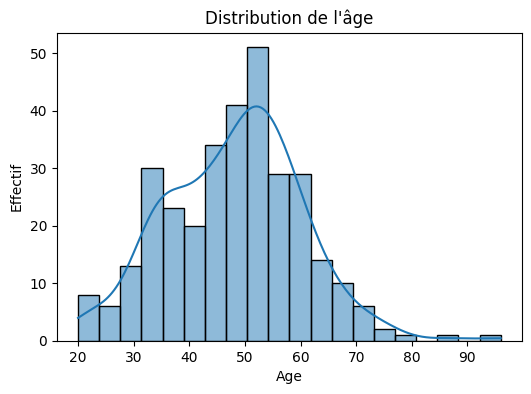

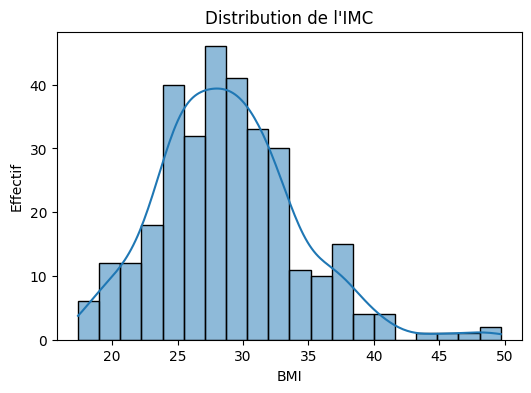

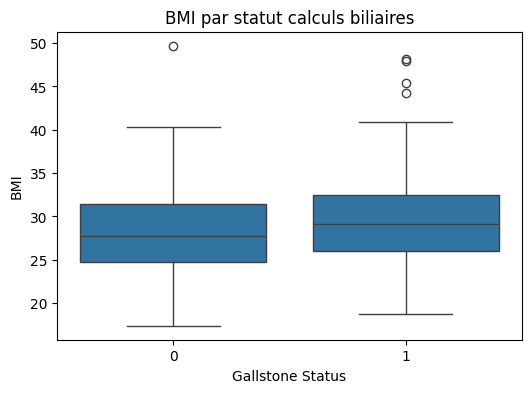

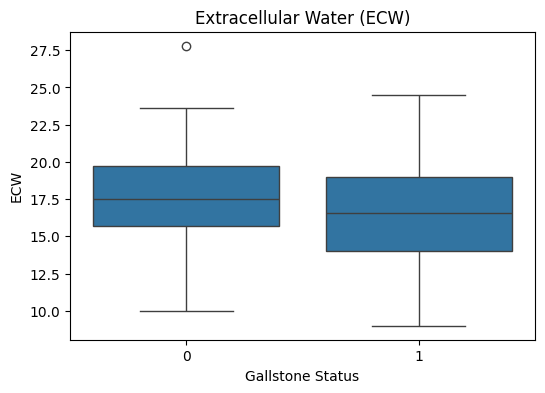

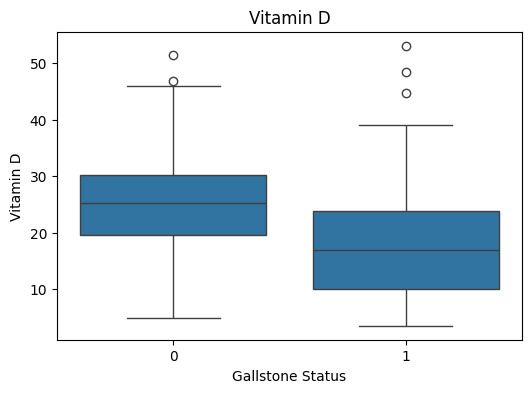

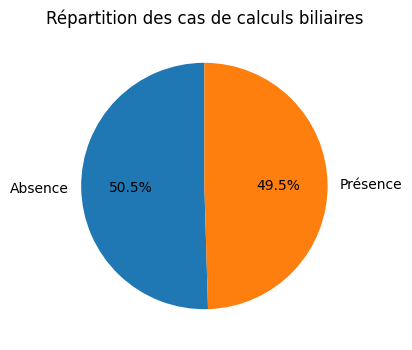

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# a) Distribution de l'âge
plt.figure(figsize=(6, 4))
sns.histplot(df['Age'], bins=20, kde=True)
plt.title('Distribution de l\'âge')
plt.xlabel('Age')
plt.ylabel('Effectif')
plt.show()

# b) Distribution de l'IMC (Body Mass Index)
if "Body Mass Index (BMI)" in df.columns:
    plt.figure(figsize=(6, 4))
    sns.histplot(df['Body Mass Index (BMI)'], bins=20, kde=True)
    plt.title('Distribution de l\'IMC')
    plt.xlabel('BMI')
    plt.ylabel('Effectif')
    plt.show()

# c) Boxplot du BMI selon la présence de calculs
if "Body Mass Index (BMI)" in df.columns:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x='Gallstone Status', y='Body Mass Index (BMI)', data=df)
    plt.title('BMI par statut calculs biliaires')
    plt.xlabel('Gallstone Status')
    plt.ylabel('BMI')
    plt.show()
    
    # c) Boxplot du ECW selon la présence de calculs
if "Body Mass Index (BMI)" in df.columns:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x='Gallstone Status', y='Extracellular Water (ECW)', data=df)
    plt.title('Extracellular Water (ECW)')
    plt.xlabel('Gallstone Status')
    plt.ylabel('ECW')
    plt.show()
    
    # c) Boxplot de la vitamine D selon la présence de calculs
if "Body Mass Index (BMI)" in df.columns:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x='Gallstone Status', y='Vitamin D', data=df)
    plt.title('Vitamin D')
    plt.xlabel('Gallstone Status')
    plt.ylabel('Vitamin D')
    plt.show()

# d) Répartition de la variable cible
plt.figure(figsize=(4, 4))
df['Gallstone Status'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, labels=['Absence', 'Présence'])
plt.title('Répartition des cas de calculs biliaires')
plt.ylabel('')
plt.show()


Corrélations

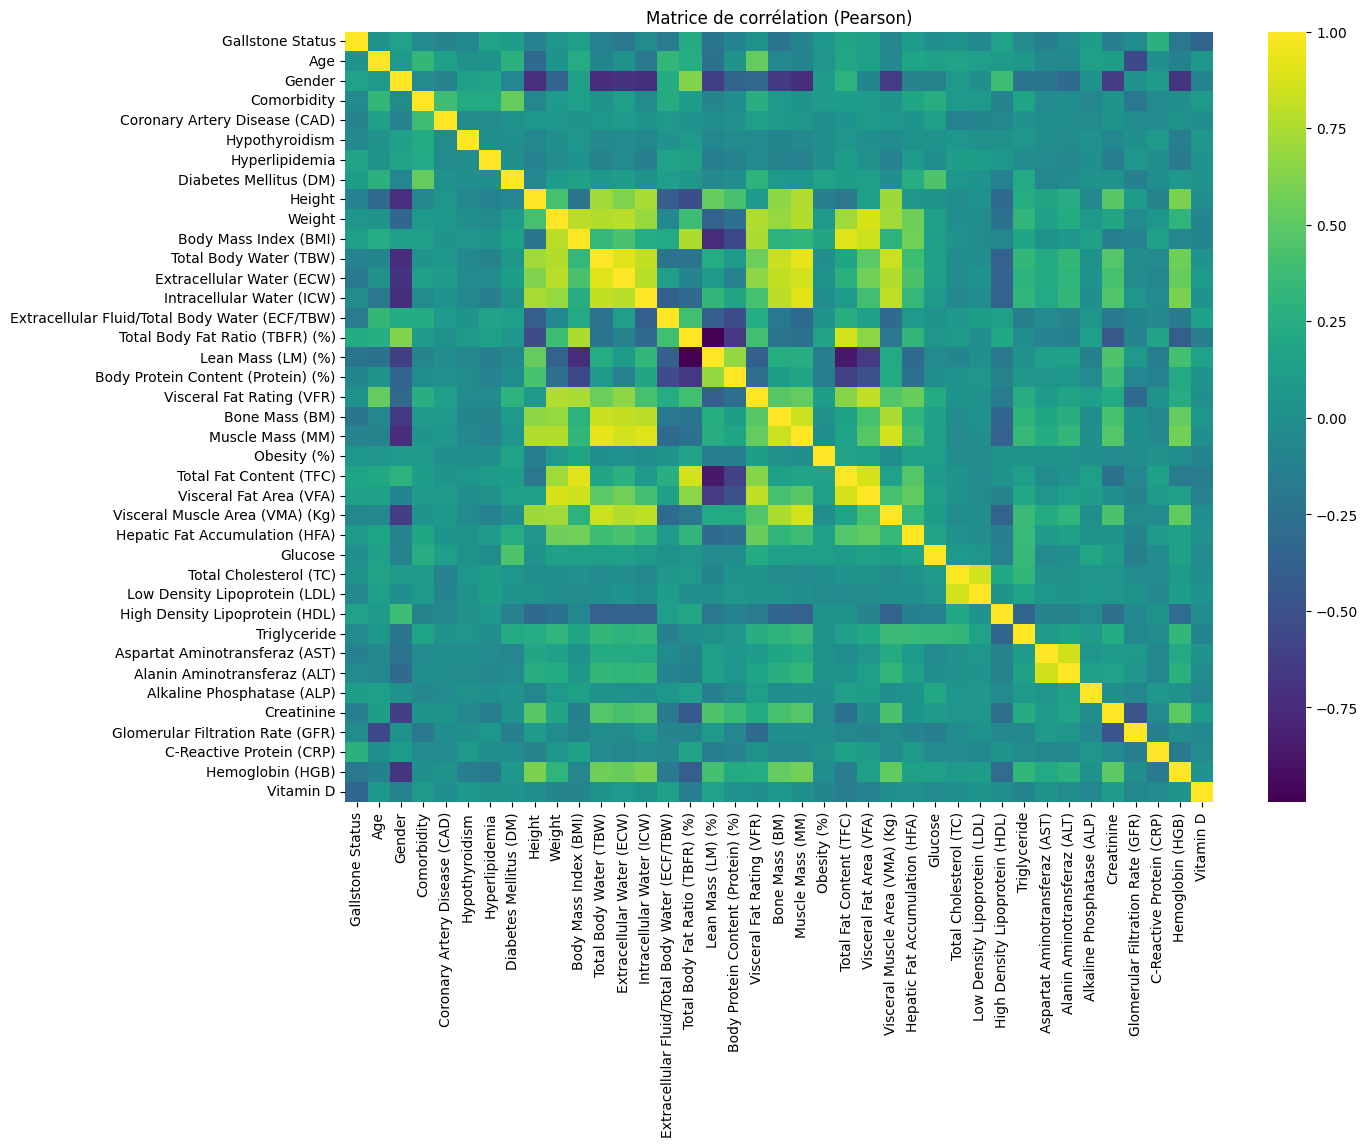

Variables les plus (positivement ou négativement) corrélées à la présence de calculs :
Gallstone Status                                  1.000000
C-Reactive Protein (CRP)                          0.281995
Total Body Fat Ratio (TBFR) (%)                   0.225470
Total Fat Content (TFC)                           0.170158
Hyperlipidemia                                    0.161901
High Density Lipoprotein (HDL)                    0.158622
Gender                                            0.153483
Visceral Fat Area (VFA)                           0.140397
Body Mass Index (BMI)                             0.121507
Alkaline Phosphatase (ALP)                        0.109882
Diabetes Mellitus (DM)                            0.104689
Hepatic Fat Accumulation (HFA)                    0.090268
Obesity (%)                                       0.053920
Weight                                            0.048669
Age                                               0.036339
Visceral Fat Rating (VFR)   

In [32]:
# a) Matrice de corrélation (seulement les colonnes numériques)
plt.figure(figsize=(14, 10))
corr = df.corr()
sns.heatmap(corr, cmap='viridis', center=0)
plt.title('Matrice de corrélation (Pearson)')
plt.show()

# b) Corrélation de chaque variable avec la cible
cor_target = corr['Gallstone Status'].sort_values(ascending=False)
print("Variables les plus (positivement ou négativement) corrélées à la présence de calculs :")
print(cor_target)

# 4. Sélection des variables : méthode SelectKBest (f_classif)

Choix du nombre K à affiner .

In [57]:
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif

X = df.drop("Gallstone Status", axis=1)
y = df["Gallstone Status"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

list_k = [5,8,12,15]
for K in list_k :
    print()
    print("Les variables selectionnées selon le K: ", K)
    selector = SelectKBest(score_func = f_classif, k=K)
    X_kbest = selector.fit_transform(X_scaled, y)
    print("Variables retenues :", list(X.columns[selector.get_support()]))

# K=8
# selector = SelectKBest(score_func = f_classif, k=K)
# X_kbest = selector.fit_transform(X_scaled, y)
# print("Variables retenues :", list(X.columns[selector.get_support()]))



Les variables selectionnées selon le K:  5
Variables retenues : ['Total Body Fat Ratio (TBFR) (%)', 'Lean Mass (LM) (%)', 'Bone Mass (BM)', 'C-Reactive Protein (CRP)', 'Vitamin D']

Les variables selectionnées selon le K:  8
Variables retenues : ['Extracellular Water (ECW)', 'Total Body Fat Ratio (TBFR) (%)', 'Lean Mass (LM) (%)', 'Bone Mass (BM)', 'Total Fat Content (TFC)', 'C-Reactive Protein (CRP)', 'Hemoglobin (HGB)', 'Vitamin D']

Les variables selectionnées selon le K:  12
Variables retenues : ['Gender', 'Hyperlipidemia', 'Extracellular Water (ECW)', 'Extracellular Fluid/Total Body Water (ECF/TBW)', 'Total Body Fat Ratio (TBFR) (%)', 'Lean Mass (LM) (%)', 'Bone Mass (BM)', 'Total Fat Content (TFC)', 'High Density Lipoprotein (HDL)', 'C-Reactive Protein (CRP)', 'Hemoglobin (HGB)', 'Vitamin D']

Les variables selectionnées selon le K:  15
Variables retenues : ['Gender', 'Hyperlipidemia', 'Extracellular Water (ECW)', 'Extracellular Fluid/Total Body Water (ECF/TBW)', 'Total Body Fat

# 5. Modélisation : entraînement du Random Forest avec validation croisée 5-fold

Les métriques sélectionnées :

'accuracy' : Taux de bonnes prédictions.

'f1' : Moyenne harmonique entre précision et rappel.

'recall' : Rappel ou sensibilité (TP / (TP + FN)).

'roc_auc' : Aire sous la courbe ROC (performance globale).

'mcc' : Matthews Correlation Coefficient — robuste même en cas de déséquilibre de classes.



In [69]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.metrics import make_scorer, matthews_corrcoef


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rf = RandomForestClassifier(random_state=42, n_estimators=100)

scoring = {
    'accuracy': 'accuracy',
    'f1': 'f1',
    'recall': 'recall',
    'roc_auc': 'roc_auc',
    'mcc': make_scorer(matthews_corrcoef)
}
results = cross_validate(rf, X_kbest, y, cv=cv, scoring=scoring, return_estimator=True)


# list_k = [5,8,12,15]
# for K in list_k :
#     print()
#     print("--- Scores en validation croisée sur", K , "folds ---")
#     cv = StratifiedKFold(n_splits=K, shuffle=True, random_state=42)
#     rf = RandomForestClassifier(random_state=42, n_estimators=100)

#     scoring = {
#         'accuracy': 'accuracy',
#         'f1': 'f1',
#         'recall': 'recall',
#         'roc_auc': 'roc_auc',
#         'mcc': make_scorer(matthews_corrcoef)
#     }
#     results = cross_validate(rf, X_kbest, y, cv=cv, scoring=scoring, return_estimator=True)
    
#     print()
#     for metric in scoring.keys():
#         print(f"{metric}: {results['test_'+metric].mean():.3f} (+/-{results['test_'+metric].std():.3f})")


Affichage des scores

In [70]:
print("--- Scores en validation croisée sur 5 folds ---")
for metric in scoring.keys():
    print(f"{metric}: {results['test_'+metric].mean():.3f} (+/-{results['test_'+metric].std():.3f})")

--- Scores en validation croisée sur 5 folds ---
accuracy: 0.771 (+/-0.042)
f1: 0.761 (+/-0.048)
recall: 0.741 (+/-0.070)
roc_auc: 0.838 (+/-0.044)
mcc: 0.545 (+/-0.082)


 matrice de confusion :

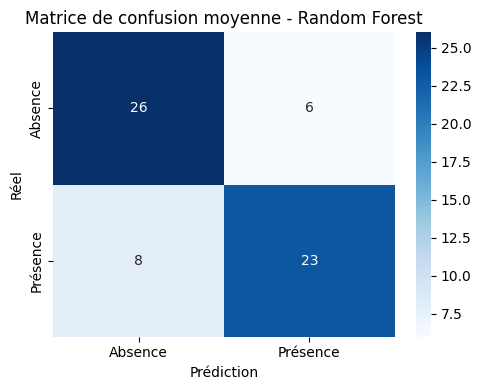

In [90]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, mean_squared_error

# Initialisation des listes pour stocker les matrices de confusion et le MSE par fold
cms = []
mses = []

# Boucle sur les splits de la validation croisée

for train_idx, test_idx in cv.split(X_kbest, y):
    rf.fit(X_kbest[train_idx], y.iloc[train_idx])
    y_pred = rf.predict(X_kbest[test_idx])
    y_true = y.iloc[test_idx]
    cms.append(confusion_matrix(y_true, y_pred))
    mses.append(mean_squared_error(y_true, y_pred))

# Calcul de la matrice de confusion moyenne
mean_cm = np.array(cms).mean(axis=0).round().astype(int)


# Affichage graphique de la matrice de confusion moyenne
plt.figure(figsize=(5, 4))
sns.heatmap(mean_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Absence', 'Présence'],
            yticklabels=['Absence', 'Présence'])
plt.title('Matrice de confusion moyenne - Random Forest')
plt.xlabel('Prédiction')
plt.ylabel('Réel')
plt.tight_layout()
plt.show()



# 6. Évaluation et interprétation des résultats

In [89]:
for metric in scoring:
    values = results['test_'+metric]
    print(f"{metric:8s}: {values.mean():.3f} (+/- {values.std():.3f})")
# Affichage du MSE moyen et de son écart-type
print(f"\nMSE moyen : {np.mean(mses):.3f} ± {np.std(mses):.3f}")


accuracy: 0.771 (+/- 0.042)
f1      : 0.761 (+/- 0.048)
recall  : 0.741 (+/- 0.070)
roc_auc : 0.838 (+/- 0.044)
mcc     : 0.545 (+/- 0.082)

MSE moyen : 0.229 ± 0.042


# 7. Comparaison avec deux autres modèles (Régression Logistique, SVM RBF)

In [88]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

models = {
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100),
    "Régression Logistique": LogisticRegression(max_iter=1000, random_state=42),
    "SVM (RBF)": SVC(kernel="rbf", probability=True, random_state=42)
}

for name, clf in models.items():
    print(f"\n== {name} ==")
    res = cross_validate(clf, X_kbest, y, cv=cv, scoring=scoring, return_estimator=True)
    for metric in scoring:
        values = res['test_'+metric]
        print(f"{metric:8s}: {values.mean():.3f} (+/- {values.std():.3f})")



== Random Forest ==
accuracy: 0.771 (+/- 0.042)
f1      : 0.761 (+/- 0.048)
recall  : 0.741 (+/- 0.070)
roc_auc : 0.838 (+/- 0.044)
mcc     : 0.545 (+/- 0.082)

== Régression Logistique ==
accuracy: 0.800 (+/- 0.052)
f1      : 0.781 (+/- 0.063)
recall  : 0.728 (+/- 0.089)
roc_auc : 0.869 (+/- 0.051)
mcc     : 0.608 (+/- 0.101)

== SVM (RBF) ==
accuracy: 0.768 (+/- 0.052)
f1      : 0.740 (+/- 0.069)
recall  : 0.678 (+/- 0.102)
roc_auc : 0.845 (+/- 0.041)
mcc     : 0.547 (+/- 0.098)


# 8. Visualisation des matrices de confusion moyennes

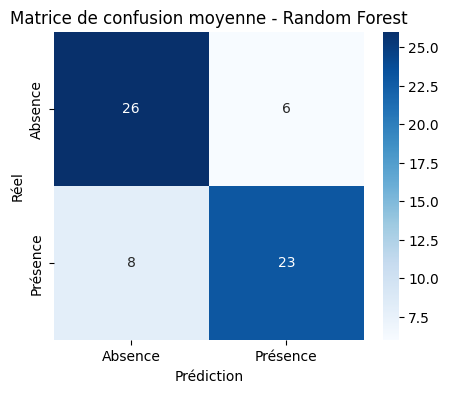

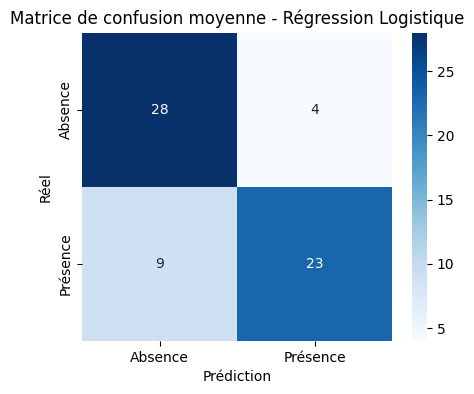

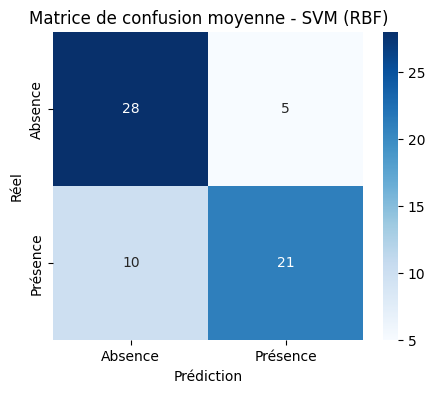

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns
for name, clf in models.items():
    cms=[]
    for train_idx, test_idx in cv.split(X_kbest, y):
        clf.fit(X_kbest[train_idx], y.iloc[train_idx])
        y_pred = clf.predict(X_kbest[test_idx])
        y_true = y.iloc[test_idx]
        cms.append(confusion_matrix(y_true, y_pred))
    mean_cm = np.array(cms).mean(axis=0).round().astype(int)
    plt.figure(figsize=(5,4))
    sns.heatmap(mean_cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Absence', 'Présence'], yticklabels=['Absence', 'Présence'])
    plt.title(f"Matrice de confusion moyenne - {name}")
    plt.xlabel('Prédiction')
    plt.ylabel('Réel')
    plt.show()


# 9. Courbes ROC, évolution score/K (pour l’annexe)

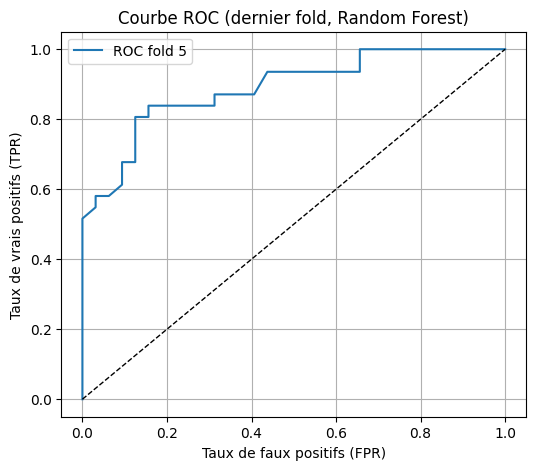

In [87]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier


# 5. ROC-AUC courbe sur le dernier fold pour exemple
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

est = results['estimator'][-1]
X_test = X_kbest[test_idx]
y_true = y.iloc[test_idx]
y_prob = est.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_true, y_prob)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label='ROC fold 5', color='C0')
plt.plot([0,1],[0,1],'k--', lw=1)
plt.xlabel('Taux de faux positifs (FPR)')
plt.ylabel('Taux de vrais positifs (TPR)')
plt.title('Courbe ROC (dernier fold, Random Forest)')
plt.legend()
plt.grid()
plt.show()

